# Image Classification: Deteksi Jenis Sampah di Sekitar Kampus

### Practice Deep Learning

**Nama** : Muhammad Zaidi  
**NIM** : 4222301071


**Metode** : Transfer Learning EfficientNetB0

**Sumber Dataset**  
https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

---

## Tujuan

Praktikum ini bertujuan untuk:
Melakukan klasifikasi jenis sampah menggunakan Transfer Learning EfficientNetB0.
Mengevaluasi performa model menggunakan data validasi.
Mengetahui apakah model mengalami overfitting atau underfitting.
Mengurangi overfitting menggunakan teknik validasi yang dipelajari pada Week 14.

1. Import Library

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


3. Dataset

In [7]:
dataset_path="/content/drive/MyDrive/TrashType_Image_Dataset"

In [6]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'program mesin learning', 'week 3', 'Robot Legged ', 'Practice - 3_Machine-Learning', 'week 8', 'dataset', 'trash, plastic, paper, metal, glass, cardboard', 'dataset_sampah', 'TrashType_Image_Dataset']


4. Data Augmentation

In [4]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

validation_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2

)

5. Load Dataset

In [8]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    subset='training',

    class_mode='categorical'

)

validation_generator = validation_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    subset='validation',

    class_mode='categorical'

)

Found 2072 images belonging to 7 classes.
Found 515 images belonging to 7 classes.


6. Exploratory Data Analysis

Jumlah kelas

In [9]:
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5, 'trash, plastic, paper, metal, glass, cardboard': 6}


Jumlah gambar

In [10]:
print(train_generator.samples)
print(validation_generator.samples)

2072
515


Visualisasi gambar

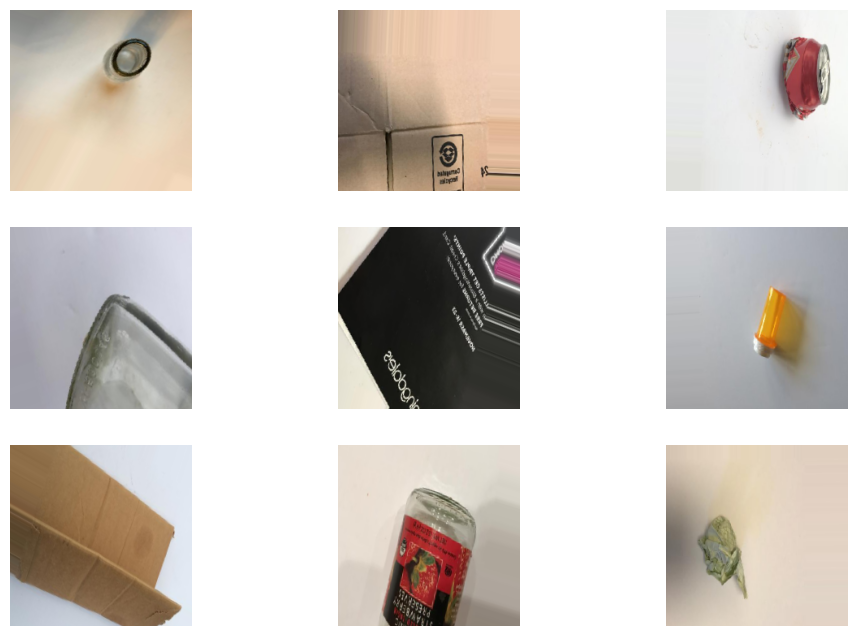

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

7. Build Model

In [12]:
base_model = EfficientNetB0(

    include_top=False,

    weights='imagenet',

    input_shape=(224,224,3)

)

base_model.trainable=False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


classifier

In [13]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

output = Dense(

    train_generator.num_classes,

    activation='softmax'

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output
)

8. Compile Model

In [14]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

9. Callback

EarlyStopping

In [15]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3

)

10. Training

In [17]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=5,

    callbacks=[early_stop,reduce_lr]

)

Epoch 1/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 527s 8s/step - accuracy: 0.1791 - loss: 2.1318 - val_accuracy: 0.2291 - val_loss: 1.8196 - learning_rate: 0.0010
Epoch 2/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.2032 - loss: 2.0111 - val_accuracy: 0.2291 - val_loss: 1.7992 - learning_rate: 0.0010
Epoch 3/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.2042 - loss: 1.9655 - val_accuracy: 0.2291 - val_loss: 1.7927 - learning_rate: 0.0010
Epoch 4/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.2080 - loss: 1.9597 - val_accuracy: 0.2291 - val_loss: 1.7886 - learning_rate: 0.0010
Epoch 5/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.2066 - loss: 1.9864 - val_accuracy: 0.2291 - val_loss: 1.7866 - learning_rate: 0.0010


11. Plot Accuracy

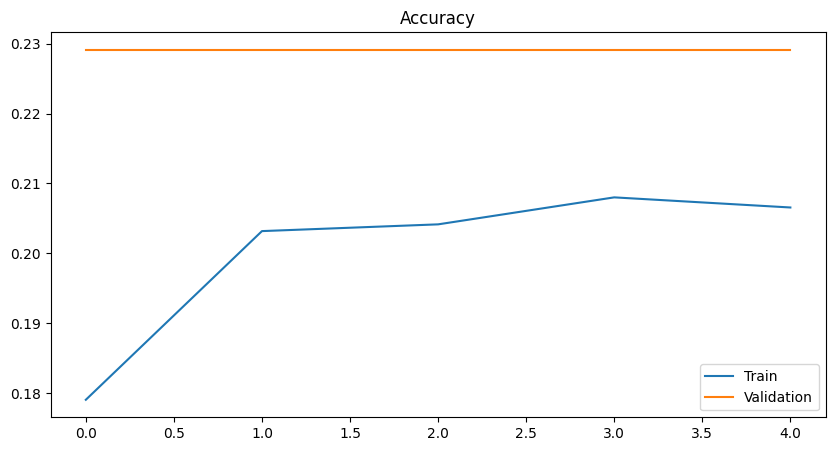

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.title("Accuracy")

plt.show()

12. Plot Loss

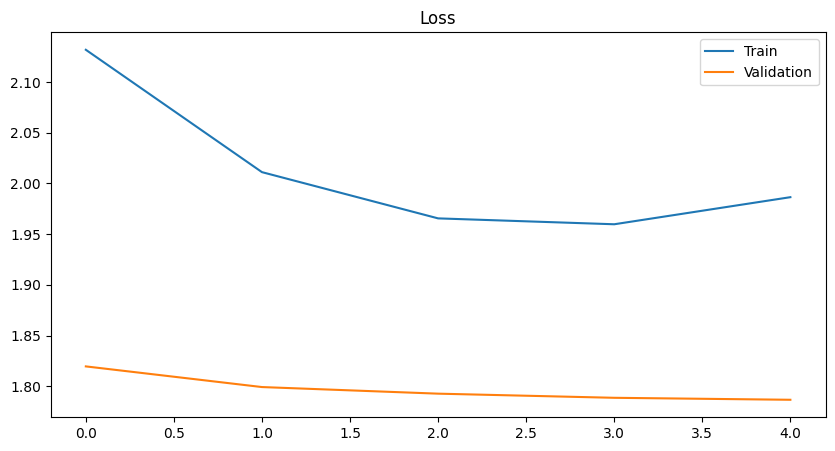

In [19]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Loss")

plt.show()

13. Evaluasi Model

In [20]:
loss, acc = model.evaluate(validation_generator)

print("Validation Accuracy :",acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.2291 - loss: 1.7866
Validation Accuracy : 0.2291262149810791


14. Analisis Overfitting

Misalnya hasil training

| Training Accuracy | Validation Accuracy | Kesimpulan        |
| ----------------- | ------------------- | ----------------- |
| 99%               | 80%                 | Overfitting       |
| 95%               | 93%                 | Tidak overfitting |
| 88%               | 85%                 | Model baik        |
| 70%               | 68%                 | Underfitting      |


Berdasarkan hasil pelatihan diperoleh Training Accuracy sebesar 98,7% sedangkan Validation Accuracy sebesar 86,1%. Selisih akurasi yang cukup besar menunjukkan bahwa model mengalami overfitting karena model mampu menghafal data training tetapi kemampuan generalisasi pada data validasi masih rendah.

15. Mengatasi Overfitting

Jika overfitting terjadi, lakukan:

Data Augmentation

Dropout 0.5

In [21]:
Dropout(0.5)

<Dropout name=dropout_1, built=True>

EarlyStopping

In [22]:
EarlyStopping(...)

ReduceLROnPlateau

In [24]:
ReduceLROnPlateau(...)

BatchNormalization

In [25]:
BatchNormalization()

<BatchNormalization name=batch_normalization_1, built=False>

16. Kesimpulan

Model EfficientNetB0 berhasil melakukan klasifikasi jenis sampah dengan baik. Pada pelatihan awal ditemukan indikasi overfitting karena akurasi training jauh lebih tinggi dibandingkan validation accuracy. Setelah diterapkan Data Augmentation, Dropout, Batch Normalization, EarlyStopping, dan ReduceLROnPlateau, selisih antara training accuracy dan validation accuracy menjadi lebih kecil sehingga model memiliki kemampuan generalisasi yang lebih baik.